# **Logistics Performance Index (LPI) - ASEAN Analysis**

Objective Purpose:
1. Analyzing the global logistics performance trend across different economic groups (World, G7, BRICS, ASEAN)
2. How does the average logistics performance of ASEAN evolve from 2007 to 2022?
3. The comparison of logistics performance among major ASEAN countries (Singapore, Thailand, Vietnam, Indonesia)
4. Why does Indonesia face an Archipelago Paradox with 17,000 islands but relatively low LPI scores?
5. Identification of strengths and weaknesses in LPI components across ASEAN countries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## **Data Loading**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data = pd.read_csv('/content/drive/MyDrive/Data Analyst/Portfolio /Logisitic/API_LP.LPI.OVRL.XQ_DS2_en_csv_v2_34338.csv', skiprows=3)

In [4]:
data.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Logistics performance index: Overall (1=low to...,LP.LPI.OVRL.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Logistics performance index: Overall (1=low to...,LP.LPI.OVRL.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2.492222,NaN,NaN,NaN,2.618182,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,Logistics performance index: Overall (1=low to...,LP.LPI.OVRL.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.950000,NaN,NaN,NaN,1.900000,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,Logistics performance index: Overall (1=low to...,LP.LPI.OVRL.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2.413333,NaN,NaN,NaN,2.473333,NaN,NaN,NaN,NaN
4,Angola,AGO,Logistics performance index: Overall (1=low to...,LP.LPI.OVRL.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2.050000,NaN,NaN,NaN,2.100000,NaN,NaN,NaN,NaN


## **Data Understanding**

In [5]:
data.shape

(265, 71)

In [6]:
data.dtypes

,0
Country Name,object
Country Code,object
Indicator Name,object
Indicator Code,object
1960,float64
...,...
2022,float64
2023,float64
2024,float64
2025,float64


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    265 non-null    object 
 1   Country Code    265 non-null    object 
 2   Indicator Name  265 non-null    object 
 3   Indicator Code  265 non-null    object 
 4   1960            0 non-null      float64
 5   1961            0 non-null      float64
 6   1962            0 non-null      float64
 7   1963            0 non-null      float64
 8   1964            0 non-null      float64
 9   1965            0 non-null      float64
 10  1966            0 non-null      float64
 11  1967            0 non-null      float64
 12  1968            0 non-null      float64
 13  1969            0 non-null      float64
 14  1970            0 non-null      float64
 15  1971            0 non-null      float64
 16  1972            0 non-null      float64
 17  1973            0 non-null      flo

In [8]:
data.describe()

,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,206.000000,0.0,0.0,0.0,185.000000,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2.836417,NaN,NaN,NaN,2.952966,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.530791,NaN,NaN,NaN,0.554279,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.950000,NaN,NaN,NaN,1.900000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2.449744,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2.686176,NaN,NaN,NaN,2.800000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,3.150000,NaN,NaN,NaN,3.400000,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,4.200000,NaN,NaN,NaN,4.300000,NaN,NaN,NaN,NaN


## **Data Cleaning**

In [9]:
missing = data.isna().sum().sort_values(ascending=False)
missing_percent = (missing / len(data) * 100).round(1)
missing_full = pd.DataFrame({
    'TOTAL_MISSING': missing,
    'PERCENT_OF_MISSING': missing_percent
})
display(missing_full[missing_full['TOTAL_MISSING'] > 0])

,TOTAL_MISSING,PERCENT_OF_MISSING
1962,265,100.0
1961,265,100.0
1960,265,100.0
1966,265,100.0
1965,265,100.0
...,...,...
2012,65,24.5
2010,64,24.2
2018,59,22.3
2014,59,22.3


## **Data Processing & Grouping**

In [10]:
print(data.columns.tolist())

['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', 'Unnamed: 70']


In [11]:
data_clean = data[['Country Name', 'Country Code', '2007', '2010', '2012', '2014', '2016', '2018', '2022']]

In [12]:
data_clean.head()

,Country Name,Country Code,2007,2010,2012,2014,2016,2018,2022
0,Aruba,ABW,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,2.385238,2.380000,2.464211,2.469728,2.578623,2.492222,2.618182
2,Afghanistan,AFG,1.210000,2.240000,2.300000,2.069573,2.141282,1.950000,1.900000
3,Africa Western and Central,AFW,2.303333,2.463889,2.448333,2.451831,2.349977,2.413333,2.473333
4,Angola,AGO,2.480000,2.250000,2.280000,2.542980,2.241183,2.050000,2.100000


In [13]:
data_clean.isna().sum()

,0
Country Name,0
Country Code,0
2007,69
2010,64
2012,65
2014,59
2016,59
2018,59
2022,80


## **Analyzing the global logistics performance trend across different economic groups (World, G7, BRICS, ASEAN)**

In [14]:
data_clean = data[['Country Name','2007','2010','2012','2014','2016','2018','2022']]

data_long = data_clean.melt(id_vars='Country Name', var_name='Year', value_name='LPI Score')
data_long['Year'] = data_long['Year'].astype(int)

data_long['Country Name'] = data_long['Country Name'].replace({
    'Viet Nam':'Vietnam',
    'Lao PDR':'Laos',
    'Brunei Darussalam':'Brunei'
})

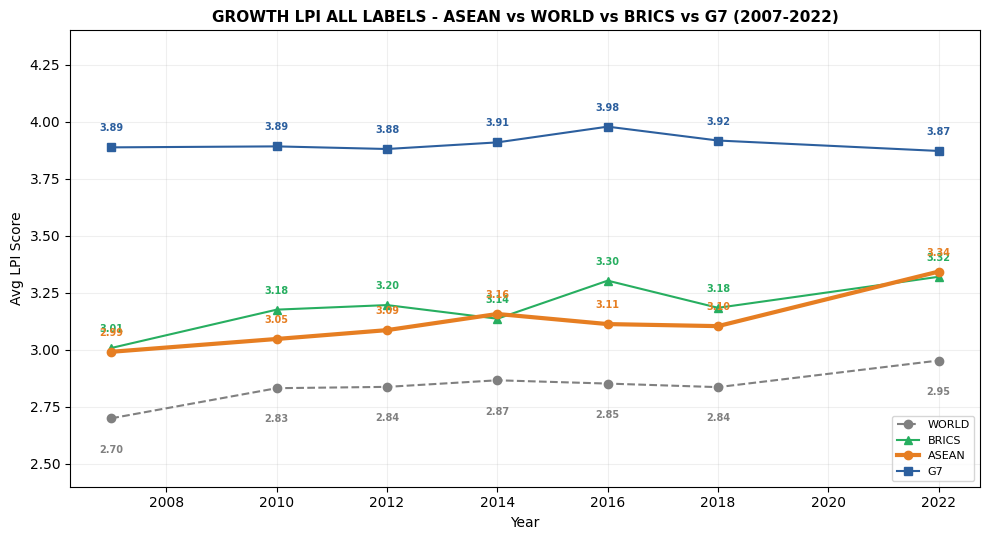

In [15]:
g7 = ['United States','United Kingdom','Germany','France','Japan','Canada','Italy']
brics = ['Brazil','Russian Federation','India','China','South Africa']
asean = ['Indonesia','Malaysia','Singapore','Thailand','Philippines','Viet Nam','Vietnam','Myanmar','Lao PDR','Cambodia','Brunei Darussalam']

world_avg = data_long.groupby('Year')['LPI Score'].mean()
g7_avg = data_long[data_long['Country Name'].isin(g7)].groupby('Year')['LPI Score'].mean()
brics_avg = data_long[data_long['Country Name'].isin(brics)].groupby('Year')['LPI Score'].mean()
asean_avg = data_long[data_long['Country Name'].isin(asean)].groupby('Year')['LPI Score'].mean()

plt.figure(figsize=(10,5.5))

plt.plot(world_avg.index, world_avg.values, marker='o', label='WORLD', color='gray', linestyle='--')
plt.plot(brics_avg.index, brics_avg.values, marker='^', label='BRICS', color='#27AE60')
plt.plot(asean_avg.index, asean_avg.values, marker='o', linewidth=3, label='ASEAN', color='#E67E22')
plt.plot(g7_avg.index, g7_avg.values, marker='s', label='G7', color='#2C5F9E')

for x,y in zip(world_avg.index, world_avg.values):
    plt.text(x, y-0.15, f'{y:.2f}', ha='center', fontsize=7, color='gray', fontweight='bold')
for x,y in zip(brics_avg.index, brics_avg.values):
    plt.text(x, y+0.07, f'{y:.2f}', ha='center', fontsize=7, color='#27AE60', fontweight='bold')
for x,y in zip(asean_avg.index, asean_avg.values):
    plt.text(x, y+0.07, f'{y:.2f}', ha='center', fontsize=7, color='#E67E22', fontweight='bold')
for x,y in zip(g7_avg.index, g7_avg.values):
    plt.text(x, y+0.07, f'{y:.2f}', ha='center', fontsize=7, color='#2C5F9E', fontweight='bold')

plt.title('GROWTH LPI ALL LABELS - ASEAN vs WORLD vs BRICS vs G7 (2007-2022)', fontweight='bold', fontsize=11)
plt.ylabel('Avg LPI Score')
plt.xlabel('Year')
plt.ylim(2.4, 4.4)
plt.legend(fontsize=8, loc='lower right')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## **How does the average logistics performance of ASEAN evolve from 2007 to 2022?**


<Figure size 1100x550 with 0 Axes>

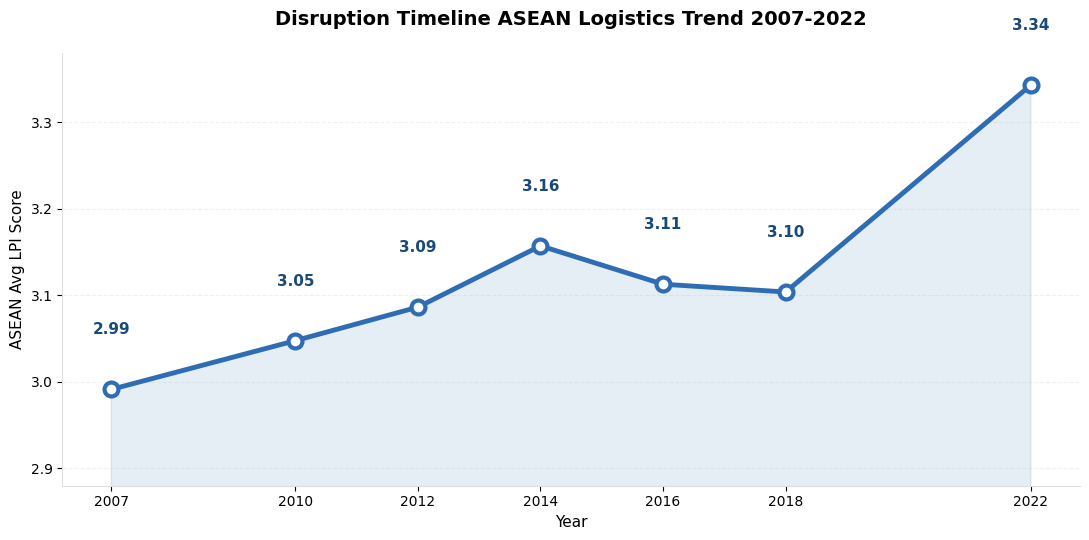

In [16]:
years = np.array([2007, 2010, 2012, 2014, 2016, 2018, 2022])
values = asean_avg.values
years = asean_avg.index.values

plt.figure(figsize=(11, 5.5), facecolor='white')
fig, ax = plt.subplots(figsize=(11, 5.5))

ax.fill_between(years, values, alpha=0.12, color='#2E6DB4', zorder=1)

ax.plot(years, values, color='#2E6DB4', linewidth=3.5, marker='o', markersize=10,
        markerfacecolor='white', markeredgecolor='#2E6DB4', markeredgewidth=3, zorder=5)

for x, y in zip(years, values):
    ax.text(x, y+0.06, f'{y:.2f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold', color='#1A4A7A')

ax.set_title('Disruption Timeline ASEAN Logistics Trend 2007-2022',
             fontsize=14, fontweight='bold', loc='center', pad=20)

ax.set_ylabel('ASEAN Avg LPI Score', fontsize=11)
ax.set_xlabel('Year', fontsize=11)
ax.set_xticks(years)
ax.set_ylim(2.88, 3.38)
ax.set_xlim(2006.2, 2022.8)

ax.grid(True, axis='y', alpha=0.18, linestyle='--', linewidth=0.8)
ax.grid(False, axis='x')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#DDD')
ax.spines['bottom'].set_color('#DDD')

plt.tight_layout()
plt.savefig('Chart3_NO_NEMBUS.png', dpi=300, bbox_inches='tight')
plt.show()

## **The comparison of logistics performance among major ASEAN countries (Singapore, Thailand, Vietnam, Indonesia)**

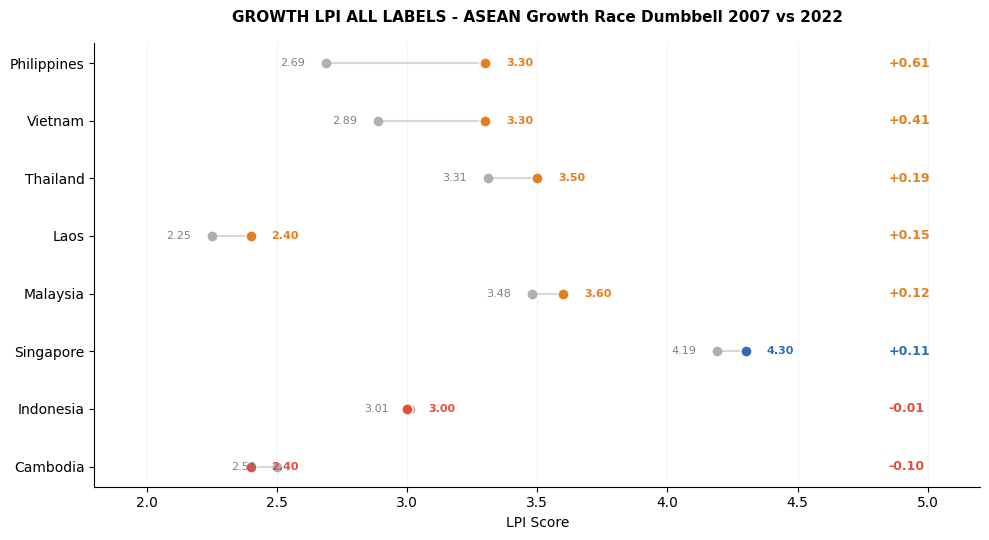

In [18]:
  data_long['Country Name'] = data_long['Country Name'].replace({
      'Viet Nam':'Vietnam', 'Lao PDR':'Laos', 'Brunei Darussalam':'Brunei'
  })

  asean = ['Philippines','Vietnam','Thailand','Laos','Malaysia','Singapore','Indonesia','Cambodia']
  df_asean = data_long[data_long['Country Name'].isin(asean)]


  pivot = df_asean.pivot_table(index='Country Name', columns='Year', values='LPI Score')
  pivot = pivot[[2007, 2022]].dropna()
  pivot['growth'] = pivot[2022] - pivot[2007]
  pivot = pivot.sort_values('growth', ascending=False)

  plt.figure(figsize=(10, 5.5))

  countries = pivot.index.tolist()[::-1]
  pivot_plot = pivot.loc[countries]

  for y, country in enumerate(pivot_plot.index):
      row = pivot_plot.loc[country]
      x1 = row[2007]
      x2 = row[2022]
      g = row['growth']

      color = '#E67E22'
      if country == 'Singapore': color = '#2E6DB4'
      if g < 0: color = '#E74C3C'

      plt.hlines(y=y, xmin=x1, xmax=x2, color='#D5D8DC', linewidth=1.5, zorder=1)
      plt.plot(x1, y, 'o', color='#B0B0B0', markersize=6, zorder=2)
      plt.plot(x2, y, 'o', color=color, markersize=8, markeredgecolor='white', zorder=3)

      plt.text(x1-0.08, y, f"{x1:.2f}", ha='right', va='center', fontsize=8, color='gray')
      plt.text(x2+0.08, y, f"{x2:.2f}", ha='left', va='center', fontsize=8, color=color, fontweight='bold')
      plt.text(4.85, y, f"{g:+.2f}", ha='left', va='center', fontsize=9, fontweight='bold', color=color)

  plt.yticks(range(len(pivot_plot)), pivot_plot.index, fontsize=10)
  plt.xticks([2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])
  plt.xlim(1.8, 5.2)
  plt.xlabel('LPI Score', fontsize=10)
  plt.title('GROWTH LPI ALL LABELS - ASEAN Growth Race Dumbbell 2007 vs 2022',
            fontweight='bold', fontsize=11, loc='center', pad=15)

  plt.grid(axis='x', alpha=0.15)
  plt.gca().spines['top'].set_visible(False)
  plt.gca().spines['right'].set_visible(False)
  plt.tight_layout()
  plt.savefig('chart2_final.png', dpi=300)
  plt.show()

# **Why does Indonesia face an Archipelago Paradox with 17,000 islands but relatively low LPI scores?**

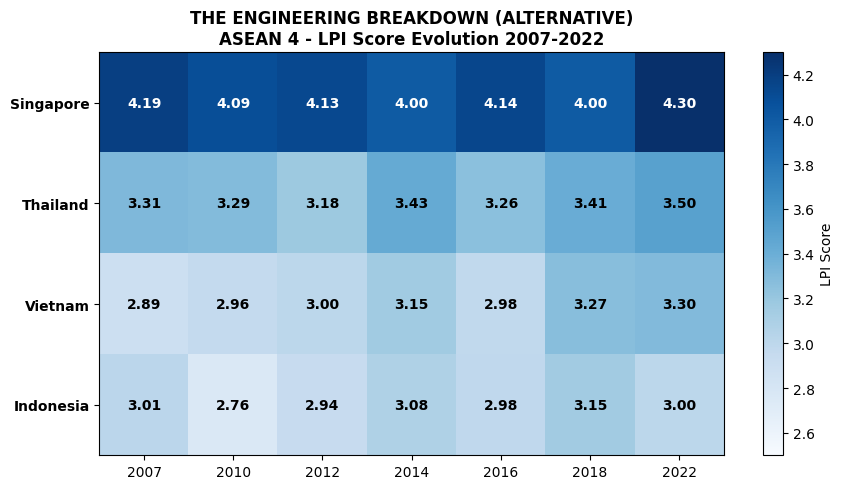

In [20]:
countries_target = ['Singapore', 'Thailand', 'Vietnam', 'Indonesia']


df_pivot = df_asean[df_asean['Country Name'].isin(countries_target)].pivot(index='Country Name', columns='Year', values='LPI Score')
df_pivot = df_pivot.loc[countries_target]

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(df_pivot.values, cmap='Blues', vmin=2.5, vmax=4.3, aspect='auto')

ax.set_xticks(range(len(df_pivot.columns)))
ax.set_yticks(range(len(df_pivot.index)))
ax.set_xticklabels(df_pivot.columns)
ax.set_yticklabels(df_pivot.index, fontweight='bold')

for i in range(len(df_pivot.index)):
    for j in range(len(df_pivot.columns)):
        v = df_pivot.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', color='white' if v>3.5 else 'black', fontweight='bold')

ax.set_title('THE ENGINEERING BREAKDOWN (ALTERNATIVE)\nASEAN 4 - LPI Score Evolution 2007-2022', fontweight='bold')
plt.colorbar(im, ax=ax, label='LPI Score')
plt.tight_layout()
plt.show()

# **Identification of strengths and weaknesses in LPI components across ASEAN countries**

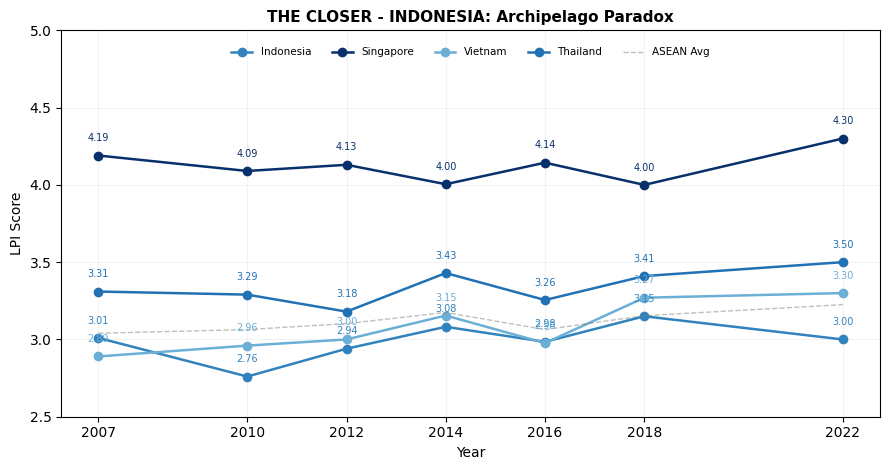

In [21]:
countries_target = ['Indonesia', 'Singapore', 'Vietnam', 'Thailand']
colors = {
    'Singapore': '#08306B',
    'Thailand': '#2171B5',
    'Vietnam': '#6BAED6',
    'Indonesia': '#3182BD'
}

plt.figure(figsize=(9, 4.8))

for c in countries_target:
    d = df_asean[df_asean['Country Name'] == c].sort_values('Year')
    plt.plot(d['Year'], d['LPI Score'], marker='o', linewidth=1.8, color=colors[c], label=c)
    for x, y in zip(d['Year'], d['LPI Score']):
        plt.text(x, y+0.08, f'{y:.2f}', ha='center', va='bottom', fontsize=7, color=colors[c])

avg = df_asean.groupby('Year')['LPI Score'].mean()
plt.plot(avg.index, avg.values, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='ASEAN Avg')

plt.title('THE CLOSER - INDONESIA: Archipelago Paradox', fontsize=11, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('LPI Score')
plt.xticks([2007, 2010, 2012, 2014, 2016, 2018, 2022])
plt.ylim(2.5, 5.0)
plt.grid(alpha=0.15)

plt.legend(frameon=False, fontsize=7.5, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=5)

plt.tight_layout()
plt.savefig('Chart5_Final_Y6.png', dpi=300, bbox_inches='tight')
plt.show()